In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

In [ ]:
df = pd.read_csv('/content/AP001.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (59150, 23)


,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (deg),SR (W/mt2),BP (mmHg),VWS (m/s),Xylene (ug/m3),RF (mm),AT (degree C)
0,01-07-2016 10:00,01-07-2016 11:00,10.67,39.0,17.67,39.2,32.33,7.07,6.60,0.48,...,33.43,71.67,2.30,226.33,123.67,NaN,-0.1,0.1,0.0,23.05
1,01-07-2016 11:00,01-07-2016 12:00,2.00,39.0,20.50,41.9,35.80,7.40,NaN,0.49,...,33.70,70.00,2.50,223.00,186.00,NaN,-0.1,0.1,0.0,NaN
2,01-07-2016 12:00,01-07-2016 13:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01-07-2016 13:00,01-07-2016 14:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01-07-2016 14:00,01-07-2016 15:00,20.50,50.0,15.40,43.6,32.78,6.35,6.38,0.47,...,33.57,63.50,1.88,223.00,240.50,NaN,-0.1,0.1,0.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59150 entries, 0 to 59149
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   From Date        59150 non-null  object 
 1   To Date          59150 non-null  object 
 2   PM2.5 (ug/m3)    54323 non-null  float64
 3   PM10 (ug/m3)     54450 non-null  float64
 4   NO (ug/m3)       55153 non-null  float64
 5   NO2 (ug/m3)      55100 non-null  float64
 6   NOx (ppb)        55315 non-null  float64
 7   NH3 (ug/m3)      53564 non-null  float64
 8   SO2 (ug/m3)      54285 non-null  float64
 9   CO (mg/m3)       54673 non-null  float64
 10  Ozone (ug/m3)    54567 non-null  float64
 11  Benzene (ug/m3)  55213 non-null  float64
 12  Toluene (ug/m3)  55213 non-null  float64
 13  Temp (degree C)  55113 non-null  float64
 14  RH (%)           55281 non-null  float64
 15  WS (m/s)         55299 non-null  float64
 16  WD (deg)         54656 non-null  float64
 17  SR (W/mt2)  

In [ ]:
features = [
    'PM2.5 (ug/m3)',
    'PM10 (ug/m3)',
    'NO2 (ug/m3)',
    'SO2 (ug/m3)',
    'CO (mg/m3)'
]

data = df[features]

In [ ]:
data = data.dropna()

print("Clean Dataset Shape:",data.shape)

Clean Dataset Shape: (51910, 5)


In [ ]:
data.describe()

,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3)
count,51910.000000,51910.000000,51910.000000,51910.000000,51910.000000
mean,29.873006,58.848830,39.640689,5.795778,0.638120
std,21.412689,32.382798,30.913759,4.562068,0.849965
min,0.250000,1.000000,0.100000,0.030000,0.000000
25%,13.250000,34.250000,17.850000,3.650000,0.350000
50%,24.250000,53.750000,31.050000,5.150000,0.580000
75%,42.750000,78.750000,53.327500,7.000000,0.790000
max,449.500000,929.000000,313.650000,199.770000,41.100000


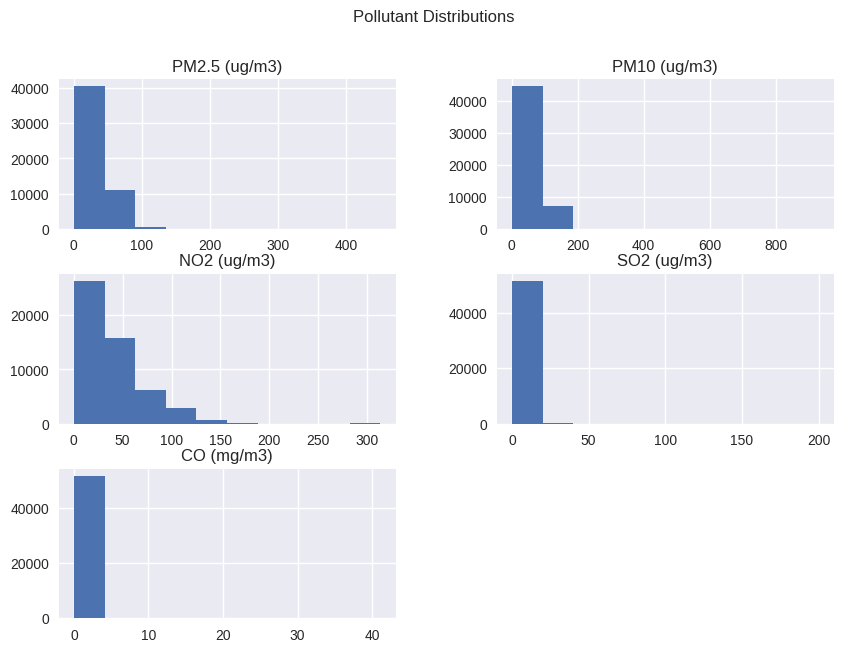

In [ ]:
data.hist(figsize=(10,7))

plt.suptitle("Pollutant Distributions")

plt.show()

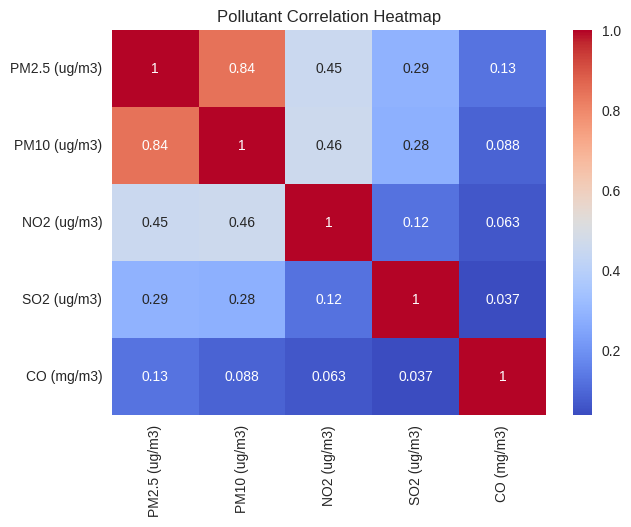

In [ ]:
plt.figure(figsize=(7,5))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Pollutant Correlation Heatmap")

plt.show()

In [ ]:
print(df.columns.tolist())

['From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)', 'Temp (degree C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'Xylene (ug/m3)', 'RF (mm)', 'AT (degree C)']


In [ ]:
features = [col for col in df.columns if any(x in col for x in ['PM2.5','PM10','NO2','SO2','CO'])]

print("Selected Features:",features)

data = df[features]

print("Shape:",data.shape)

data.head()

Selected Features: ['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)']
Shape: (59150, 5)


,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3)
0,10.67,39.0,39.2,6.60,0.48
1,2.00,39.0,41.9,NaN,0.49
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,20.50,50.0,43.6,6.38,0.47


In [ ]:
data = data.apply(pd.to_numeric, errors='coerce')

data = data.fillna(data.mean())

X = data.values.astype(float)

X_norm = (X - X.mean(axis=0)) / X.std(axis=0)

print("Data ready:", X_norm.shape)

Data ready: (59150, 5)


In [ ]:
def kmeans_custom(data, k, iterations=100):

    np.random.seed(42)

    centroids = data[np.random.choice(len(data), k, replace=False)]

    for i in range(iterations):

        clusters = []

        for point in data:

            distances = [np.linalg.norm(point-c) for c in centroids]

            clusters.append(np.argmin(distances))

        clusters = np.array(clusters)

        new_centroids = []

        for j in range(k):

            cluster_points = data[clusters==j]

            if len(cluster_points)>0:
                new_centroids.append(cluster_points.mean(axis=0))
            else:
                new_centroids.append(centroids[j])

        new_centroids = np.array(new_centroids)

        if np.all(centroids==new_centroids):
            break

        centroids=new_centroids

    return clusters,centroids

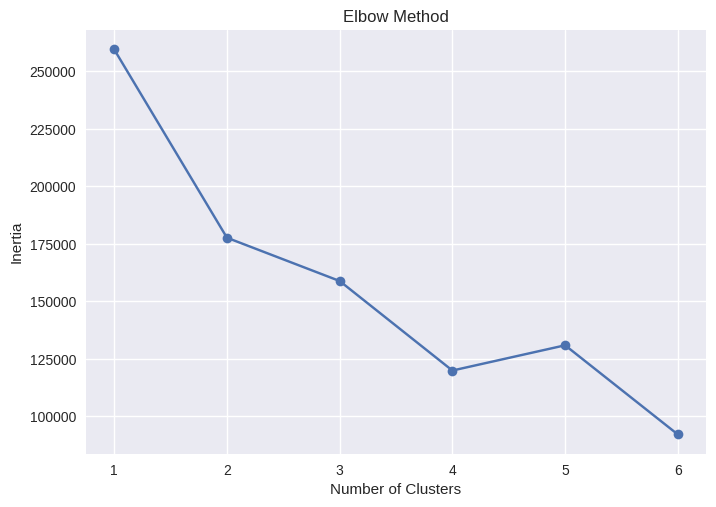

In [ ]:
def inertia(data, clusters, centroids):

    total = 0

    for i in range(len(data)):

        c = centroids[clusters[i]]

        total += np.linalg.norm(data[i]-c)**2

    return total


K = range(1,7)

errors=[]

for k in K:

    clusters,centroids=kmeans_custom(X_norm,k)

    errors.append(inertia(X_norm,clusters,centroids))


plt.plot(K,errors,'o-')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [ ]:
clusters,centroids = kmeans_custom(X_norm,3)

data['Cluster']=clusters

data.head()

,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3),Cluster
0,10.67,39.0,39.20,6.60,0.48,2
4,20.50,50.0,43.60,6.38,0.47,2
5,15.25,59.5,45.12,6.53,0.51,2
6,11.67,60.0,49.10,5.70,0.46,2
7,11.75,57.5,46.33,6.23,0.44,2


In [ ]:
cov = np.cov(X_norm.T)

eigenvalues,eigenvectors = np.linalg.eig(cov)

P = eigenvectors[:,:2]

X_pca = X_norm @ P

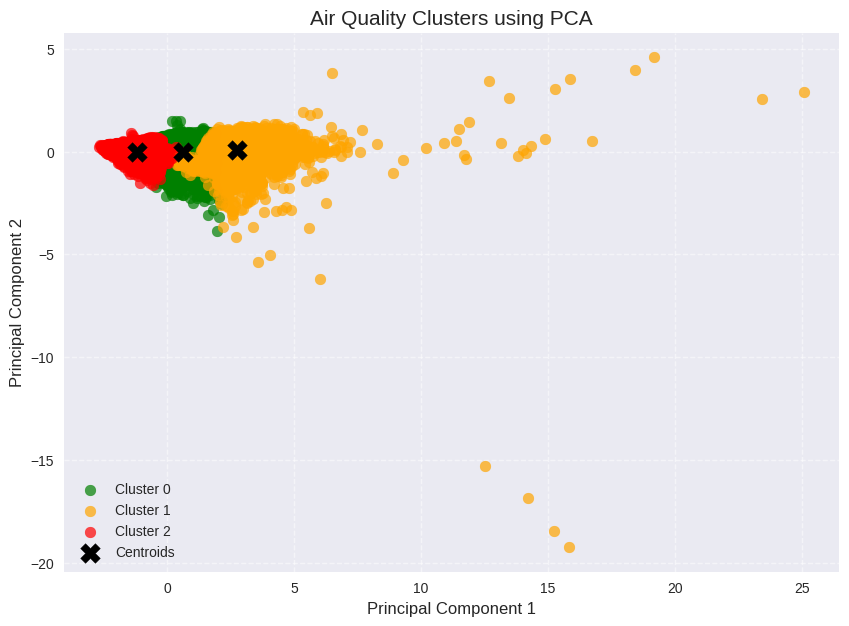

In [ ]:
plt.figure(figsize=(10,7))

# Color map for clusters
colors = ['green','orange','red']

for i in range(3):

    plt.scatter(
        X_pca[clusters==i,0],
        X_pca[clusters==i,1],
        color=colors[i],
        label=f'Cluster {i}',
        s=60,
        alpha=0.7
    )

# Plot centroids
centroids_pca = centroids @ P

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    color='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("Principal Component 1",fontsize=12)

plt.ylabel("Principal Component 2",fontsize=12)

plt.title("Air Quality Clusters using PCA",fontsize=15)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()

In [ ]:
data.groupby('Cluster').mean()

,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3)
Cluster,,,,,
0,38.496264,73.246088,46.022680,6.119706,0.604781
1,64.322391,107.929132,80.855859,9.514242,1.104098
2,14.556844,35.623023,23.934106,4.546266,0.530721


In [ ]:
labels = {
0:"Low Pollution",
1:"Moderate Pollution",
2:"High Pollution"
}

data['Pollution Level']=data['Cluster'].map(labels)

data.head()

,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3),Cluster,Pollution Level
0,10.67,39.0,39.20,6.60,0.48,2,High Pollution
4,20.50,50.0,43.60,6.38,0.47,2,High Pollution
5,15.25,59.5,45.12,6.53,0.51,2,High Pollution
6,11.67,60.0,49.10,5.70,0.46,2,High Pollution
7,11.75,57.5,46.33,6.23,0.44,2,High Pollution
